In [ ]:

# Machine Learning Models on TMDB Movie Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score,  accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Load dataset

df = pd.read_csv("tmdb_movie_details.csv")

# Keep only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove identifiers that don't help in prediction
if 'movie_id' in numeric_cols:
    numeric_cols.remove('movie_id')

df_num = df[numeric_cols].copy()


# 0) Add movie_id back so we can export predictions keyed by ID
assert 'movie_id' in df.columns, "movie_id not found in tmdb_movie_details.csv"
df_num['movie_id'] = df['movie_id'].values

# 2. Data Preprocessing

# Fill missing values with median
df_num = df_num.fillna(df_num.median())


In [ ]:
# 5. Logistic Regression (Classification Task)
# --------------------------------------------
# Create 'hit' target: 1 if revenue > budget, else 0 (your Milestone 4 rule)
df_num['hit'] = (df_num['revenue_tmdb'] > df_num['budget']).astype(int)

# FEATURES: drop the target and movie_id (we don't train on IDs)
X_class = df_num.drop(columns=['revenue_tmdb', 'hit', 'movie_id'])
y_class = df_num['hit'].copy()
ids     = df_num['movie_id'].copy()

# Split (keep ids aligned)
Xc_train, Xc_test, yc_train, yc_test, ids_train, ids_test = train_test_split(
    X_class, y_class, ids, test_size=0.2, random_state=42, stratify=y_class
)

# Scale + fit
scaler_class = StandardScaler()
Xc_train_scaled = scaler_class.fit_transform(Xc_train)
Xc_test_scaled  = scaler_class.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train_scaled, yc_train)
y_pred_class = log_reg.predict(Xc_test_scaled)

# Evaluation (unchanged)
acc  = accuracy_score(yc_test, y_pred_class)
prec = precision_score(yc_test, y_pred_class)
rec  = recall_score(yc_test, y_pred_class)
f1   = f1_score(yc_test, y_pred_class)
print(f"\nLogistic Regression\nAccuracy:{acc:.4f}  Precision:{prec:.4f}  Recall:{rec:.4f}  F1:{f1:.4f}")

cm = confusion_matrix(yc_test, y_pred_class)
print("Confusion matrix:\n", cm)

# ✅ Export predictions.csv for Power BI confusion matrix
preds = pd.DataFrame({
    'movie_id': ids_test.values,
    'actual_label': np.where(yc_test.values == 1, 'Hit', 'Flop'),
    'predicted_label': np.where(y_pred_class == 1, 'Hit', 'Flop')
})
preds.to_csv('predictions.csv', index=False)
print("Saved predictions.csv with columns: movie_id, actual_label, predicted_label")



Logistic Regression
Accuracy:0.7797  Precision:0.8378  Recall:0.7715  F1:0.8033
Confusion matrix:
 [[250  66]
 [101 341]]
Saved predictions.csv with columns: movie_id, actual_label, predicted_label


# **Linear Regression**

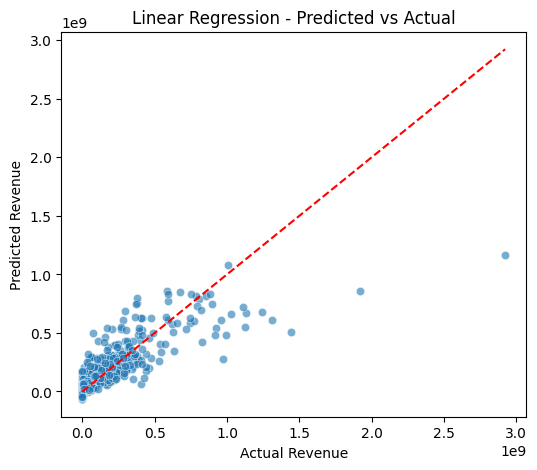


Linear Regression:
MAE: 68,494,502.09
RMSE: 134,990,834.19
R²: 0.6810


In [ ]:
# 3. Linear Regression (Regression Task)
# -----------------------------
X = df_num.drop(columns=['revenue_tmdb'])
y = df_num['revenue_tmdb']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for linear regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Visualization
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Linear Regression - Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

print("\nLinear Regression:")
print(f"MAE: {mae_lr:,.2f}")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"R²: {r2_lr:.4f}")

# **Random Forest**

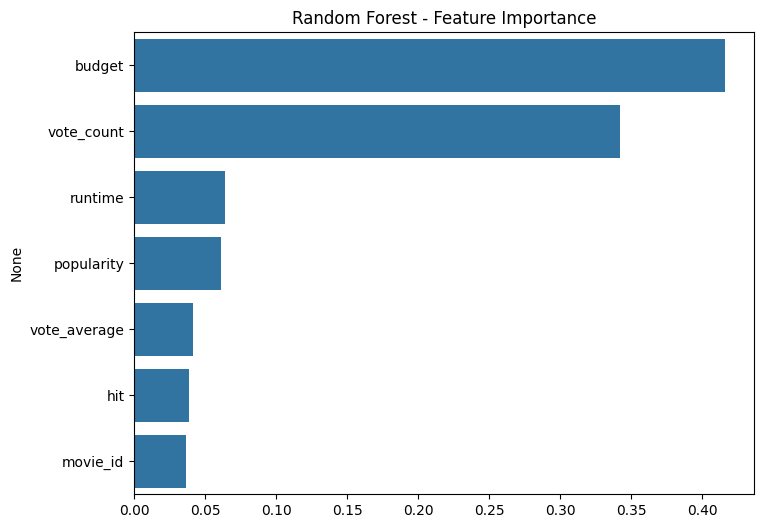


Random Forest Regressor:
MAE: 50,893,551.89
RMSE: 124,632,227.38
R²: 0.7281


In [ ]:
# 4. Random Forest Regressor (Regression Task)
# -----------------------------
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Feature Importance
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Random Forest - Feature Importance")
plt.show()

print("\nRandom Forest Regressor:")
print(f"MAE: {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²: {r2_rf:.4f}")


In [ ]:
import pandas as pd

# make sure X is a pandas DataFrame so it has .columns
fi = (pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_reg.feature_importances_
     })
     .sort_values('Importance', ascending=False))

# pretty print
print(fi.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


     Feature  Importance
      budget      0.4159
  vote_count      0.3422
     runtime      0.0637
  popularity      0.0615
vote_average      0.0414
         hit      0.0386
    movie_id      0.0367


In [ ]:
fi.to_csv('FeatureImportance.csv', index=False)
print("\nSaved to FeatureImportance.csv")



Saved to FeatureImportance.csv


## **Logistic Regression**

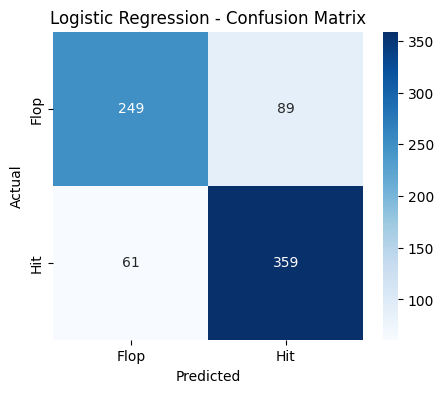


Logistic Regression:
Accuracy: 0.8021
Precision: 0.8013
Recall: 0.8548
F1-score: 0.8272


In [ ]:
# 5. Logistic Regression (Classification Task)
# -----------------------------
# Create 'hit' target: 1 if revenue > budget, else 0
df_num['hit'] = (df_num['revenue_tmdb'] > df_num['budget']).astype(int)

X_class = df_num.drop(columns=['revenue_tmdb', 'hit'])
y_class = df_num['hit']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

scaler_class = StandardScaler()
Xc_train_scaled = scaler_class.fit_transform(Xc_train)
Xc_test_scaled = scaler_class.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train_scaled, yc_train)
y_pred_class = log_reg.predict(Xc_test_scaled)

# Evaluation
acc = accuracy_score(yc_test, y_pred_class)
prec = precision_score(yc_test, y_pred_class)
rec = recall_score(yc_test, y_pred_class)
f1 = f1_score(yc_test, y_pred_class)

# Confusion Matrix
cm = confusion_matrix(yc_test, y_pred_class)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flop', 'Hit'], yticklabels=['Flop', 'Hit'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

print("\nLogistic Regression:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")


In [ ]:
# === DIAGNOSTIC: confirm feature sets match Milestone 4 ===
import hashlib

# (A) What M4 started from: numeric columns in df (minus movie_id)
numeric_cols_base = df.select_dtypes(include=[np.number]).columns.tolist()
if 'movie_id' in numeric_cols_base:
    numeric_cols_base.remove('movie_id')

print("A) Base numeric cols (df minus movie_id):")
print(numeric_cols_base, "\n")

# (B) What you trained on for regression in your script
X_reg_cols = [c for c in df_num.columns if c != 'revenue_tmdb']

# (C) What you train on for classification (should be regression cols minus target, minus movie_id, minus hit)
X_class_cols = [c for c in df_num.columns if c not in ['revenue_tmdb','hit','movie_id']]

print("B) X (regression) columns:", X_reg_cols, "\n")
print("C) X_class (classification) columns:", X_class_cols, "\n")

# Differences relative to the base numeric set (for awareness)
missing_vs_base = sorted(set(numeric_cols_base) - set(X_class_cols) - {'revenue_tmdb'})
extra_vs_base   = sorted(set(X_class_cols) - set(numeric_cols_base))
print("Diff vs base numeric (missing, extra):")
print(missing_vs_base, extra_vs_base, "\n")

# Compact signatures (just to double-check reproducibility if needed)
sig = lambda cols: hashlib.md5(("|".join(sorted(cols))).encode()).hexdigest()
print("Signatures -> X_reg:", sig(X_reg_cols), " X_class:", sig(X_class_cols))


A) Base numeric cols (df minus movie_id):
['vote_average', 'vote_count', 'popularity', 'budget', 'revenue_tmdb', 'runtime'] 

B) X (regression) columns: ['vote_average', 'vote_count', 'popularity', 'budget', 'runtime', 'movie_id', 'hit'] 

C) X_class (classification) columns: ['vote_average', 'vote_count', 'popularity', 'budget', 'runtime'] 

Diff vs base numeric (missing, extra):
[] [] 

Signatures -> X_reg: 25ea9f23c6b99ae27e6146addcf2ac23  X_class: 098efc0c4039cc00d48ba122cc690d19
